# Árvores de Decisão e Random Forest
### Disciplina: Inteligência Artificial — Graduação em Ciência da Computação

---

## Objetivos da Aula

Ao final desta aula, você será capaz de:
- Entender como uma **Árvore de Decisão** aprende a fazer perguntas sobre os dados
- Compreender os critérios de divisão: **Gini** e **Entropia**
- Identificar e controlar o **overfitting** em árvores
- Entender como o **Random Forest** combina múltiplas árvores para melhorar a performance
- Interpretar a **importância das features**
- Comparar árvores individuais vs. ensemble em um problema real

---

## 1. Motivação: Interpretabilidade vs. Performance

Na aula anterior, trabalhamos com redes neurais (MLP e CNN). Elas são poderosas, mas são **caixas-pretas**: é difícil explicar *por que* tomam uma decisão.

Árvores de Decisão têm uma vantagem única:

> **Um ser humano consegue ler e seguir a lógica da árvore passo a passo.**

Isso é fundamental em áreas como medicina, jurídico e finanças, onde decisões precisam ser **justificadas**.

```
Pergunta:  Passageiro tem idade < 18?
            ├── Sim → Sobreviveu? (provavelmente sim)
            └── Não → É mulher?
                       ├── Sim → Sobreviveu? (provavelmente sim)
                       └── Não → Está na 1ª classe?
                                   ├── Sim → ...
                                   └── Não → Não sobreviveu
```

### Comparativo com o que já vimos

| Aspecto | Rede Neural | Árvore de Decisão | Random Forest |
|---|---|---|---|
| Interpretabilidade | ❌ Baixa | ✅ Alta | ⚠️ Média |
| Performance (tabular) | ⚠️ Boa | ⚠️ Boa | ✅ Muito boa |
| Overfitting | Controlado com Dropout | Fácil de ocorrer | Robusto |
| Dados faltantes | ❌ Não tolera | ⚠️ Limitado | ✅ Tolerante |
| Tempo de treino | Lento | Rápido | Moderado |

## 2. Configuração do Ambiente

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification, make_moons, load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Estilo dos gráficos
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 3. Intuição Visual — Como a Árvore Divide o Espaço?

Antes de ir para um dataset real, vamos construir a intuição com dados sintéticos simples.

Uma Árvore de Decisão divide o espaço de features em **regiões retangulares** por meio de cortes paralelos aos eixos. Cada folha da árvore corresponde a uma região.

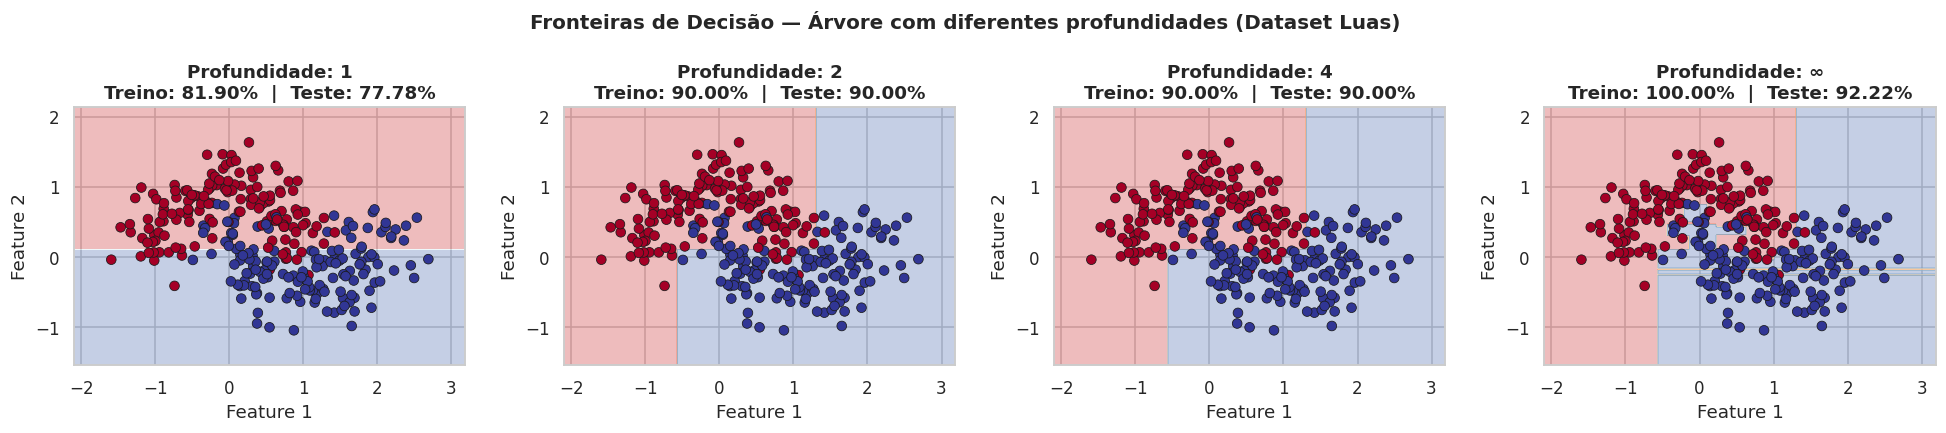

Observe: profundidade ∞ memoriza os dados de treino (overfitting)!


In [2]:
def plotar_fronteira(modelo, X, y, titulo, ax, resolucao=300):
    """Plota a fronteira de decisão de um classificador 2D."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolucao),
        np.linspace(y_min, y_max, resolucao)
    )
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu',
                         edgecolors='k', linewidths=0.5, s=40)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    return scatter

# Dataset em forma de lua (não linearmente separável)
X_luas, y_luas = make_moons(n_samples=300, noise=0.25, random_state=42)
X_tr, X_ts, y_tr, y_ts = train_test_split(X_luas, y_luas, test_size=0.3, random_state=42)

profundidades = [1, 2, 4, None]  # None = sem limite (árvore completa)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Fronteiras de Decisão — Árvore com diferentes profundidades (Dataset Luas)',
             fontsize=13, fontweight='bold')

for ax, prof in zip(axes, profundidades):
    arvore = DecisionTreeClassifier(max_depth=prof, random_state=42)
    arvore.fit(X_tr, y_tr)
    acc_tr = arvore.score(X_tr, y_tr)
    acc_ts = arvore.score(X_ts, y_ts)
    titulo = (f'Profundidade: {prof if prof else "∞"}\n'
              f'Treino: {acc_tr:.2%}  |  Teste: {acc_ts:.2%}')
    plotar_fronteira(arvore, X_luas, y_luas, titulo, ax)

plt.tight_layout()
plt.show()
print('Observe: profundidade ∞ memoriza os dados de treino (overfitting)!')

## 4. Como a Árvore Escolhe Onde Dividir?

Em cada nó, a árvore testa **todos os atributos e todos os pontos de corte possíveis** e escolhe a divisão que maximiza a **pureza** dos subconjuntos resultantes.

### 4.1 Impureza de Gini

Mede a probabilidade de classificar **incorretamente** um item escolhido ao acaso:

$$\text{Gini}(S) = 1 - \sum_{k=1}^{K} p_k^2$$

- **Gini = 0**: nó completamente puro (apenas uma classe)
- **Gini = 0,5**: máxima impureza (classes igualmente distribuídas, binário)

### 4.2 Entropia (Ganho de Informação)

Baseada no conceito de **informação** da Teoria da Informação de Shannon:

$$\text{Entropia}(S) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

O **Ganho de Informação** é a redução de entropia ao fazer uma divisão.

> **Na prática:** Gini é mais rápido (sem logaritmo) e é o padrão do scikit-learn. Os resultados costumam ser muito similares.

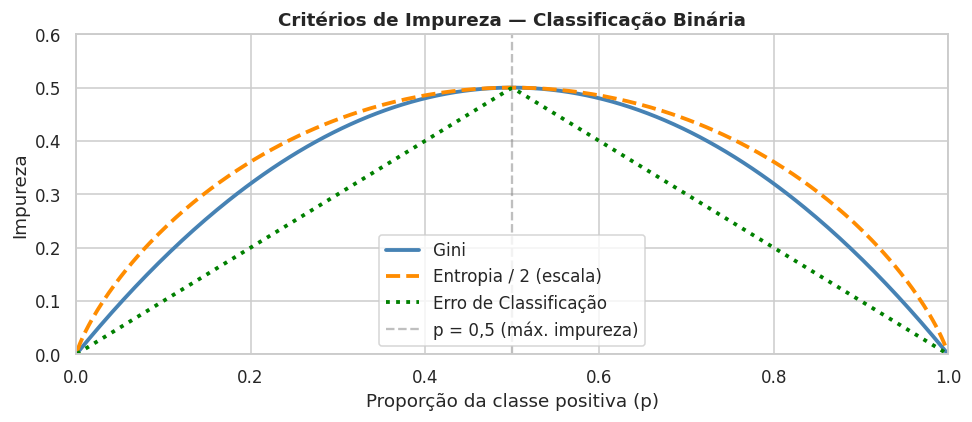

In [3]:
# Visualização das duas métricas de impureza
p = np.linspace(0.001, 0.999, 300)  # probabilidade da classe positiva

gini    = 1 - (p**2 + (1-p)**2)
entropia = -(p * np.log2(p) + (1-p) * np.log2(1-p))
erro_classif = 1 - np.maximum(p, 1-p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p, gini,         label='Gini',                  linewidth=2.5, color='steelblue')
ax.plot(p, entropia / 2, label='Entropia / 2 (escala)', linewidth=2.5, color='darkorange', linestyle='--')
ax.plot(p, erro_classif, label='Erro de Classificação', linewidth=2.5, color='green',      linestyle=':')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='p = 0,5 (máx. impureza)')
ax.set_xlabel('Proporção da classe positiva (p)')
ax.set_ylabel('Impureza')
ax.set_title('Critérios de Impureza — Classificação Binária', fontweight='bold')
ax.legend()
ax.set_xlim([0, 1]); ax.set_ylim([0, 0.6])
plt.tight_layout()
plt.show()

In [4]:
# Exemplo manual: calculando Gini para uma divisão
def gini_impureza(y):
    classes, contagens = np.unique(y, return_counts=True)
    proporcoes = contagens / len(y)
    return 1 - np.sum(proporcoes**2)

def ganho_gini(y_pai, y_esq, y_dir):
    n = len(y_pai)
    gini_ponderado = (len(y_esq)/n) * gini_impureza(y_esq) + \
                     (len(y_dir)/n) * gini_impureza(y_dir)
    return gini_impureza(y_pai) - gini_ponderado

# Exemplo: 10 pacientes, feature = temperatura, classe = doente (1) ou saudável (0)
temperaturas = [36.1, 36.5, 37.2, 37.8, 38.0, 38.3, 38.9, 39.1, 39.5, 40.0]
classes      = [    0,     0,     0,     0,     1,     0,     1,     1,     1,     1]

print('=== Exemplo: Melhor corte de temperatura para diagnosticar doença ===')
print(f'{"Corte (°C)":<12} {"Gini Esq":<12} {"Gini Dir":<12} {"Ganho":<10}')
print('-' * 50)

melhor_ganho, melhor_corte = 0, None
for i in range(1, len(temperaturas)):
    corte = (temperaturas[i-1] + temperaturas[i]) / 2
    y_esq = [c for t, c in zip(temperaturas, classes) if t <= corte]
    y_dir = [c for t, c in zip(temperaturas, classes) if t >  corte]
    ganho = ganho_gini(classes, y_esq, y_dir)
    print(f'{corte:<12.2f} {gini_impureza(y_esq):<12.4f} {gini_impureza(y_dir):<12.4f} {ganho:<10.4f}',
          '<-- MELHOR' if ganho > melhor_ganho else '')
    if ganho > melhor_ganho:
        melhor_ganho, melhor_corte = ganho, corte

=== Exemplo: Melhor corte de temperatura para diagnosticar doença ===
Corte (°C)   Gini Esq     Gini Dir     Ganho     
--------------------------------------------------
36.30        0.0000       0.4938       0.0556     <-- MELHOR
36.85        0.0000       0.4688       0.1250     <-- MELHOR
37.50        0.0000       0.4082       0.2143     <-- MELHOR
37.90        0.0000       0.2778       0.3333     <-- MELHOR
38.15        0.3200       0.3200       0.1800     
38.60        0.2778       0.0000       0.3333     
39.00        0.4082       0.0000       0.2143     
39.30        0.4688       0.0000       0.1250     
39.75        0.4938       0.0000       0.0556     


## 5. Dataset Real — Sobreviventes do Titanic

Vamos usar o famoso dataset do Titanic. O problema é:

> **Dado as características de um passageiro, ele sobreviveu ao naufrágio?**

Este é um problema de **classificação binária** com features heterogêneas (numéricas e categóricas), típico do mundo real.

### Features disponíveis

| Feature | Descrição | Tipo |
|---|---|---|
| `Pclass` | Classe do bilhete (1ª, 2ª, 3ª) | Ordinal |
| `Sex` | Sexo do passageiro | Categórico |
| `Age` | Idade | Numérico |
| `SibSp` | Nº de irmãos/cônjuges a bordo | Numérico |
| `Parch` | Nº de pais/filhos a bordo | Numérico |
| `Fare` | Valor da passagem | Numérico |
| `Embarked` | Porto de embarque (C, Q, S) | Categórico |

In [5]:
# Carrega o dataset do Titanic diretamente da URL pública
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dimensões: {df.shape}  ({df.shape[0]} passageiros, {df.shape[1]} colunas)')
print(f'\nValores faltantes por coluna:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nDistribuição do alvo:')
print(df['Survived'].value_counts().rename({0: 'Não sobreviveu', 1: 'Sobreviveu'}))
df.head()

Dimensões: (891, 12)  (891 passageiros, 12 colunas)

Valores faltantes por coluna:
Age         177
Cabin       687
Embarked      2
dtype: int64

Distribuição do alvo:
Survived
Não sobreviveu    549
Sobreviveu        342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 5.1 Análise Exploratória

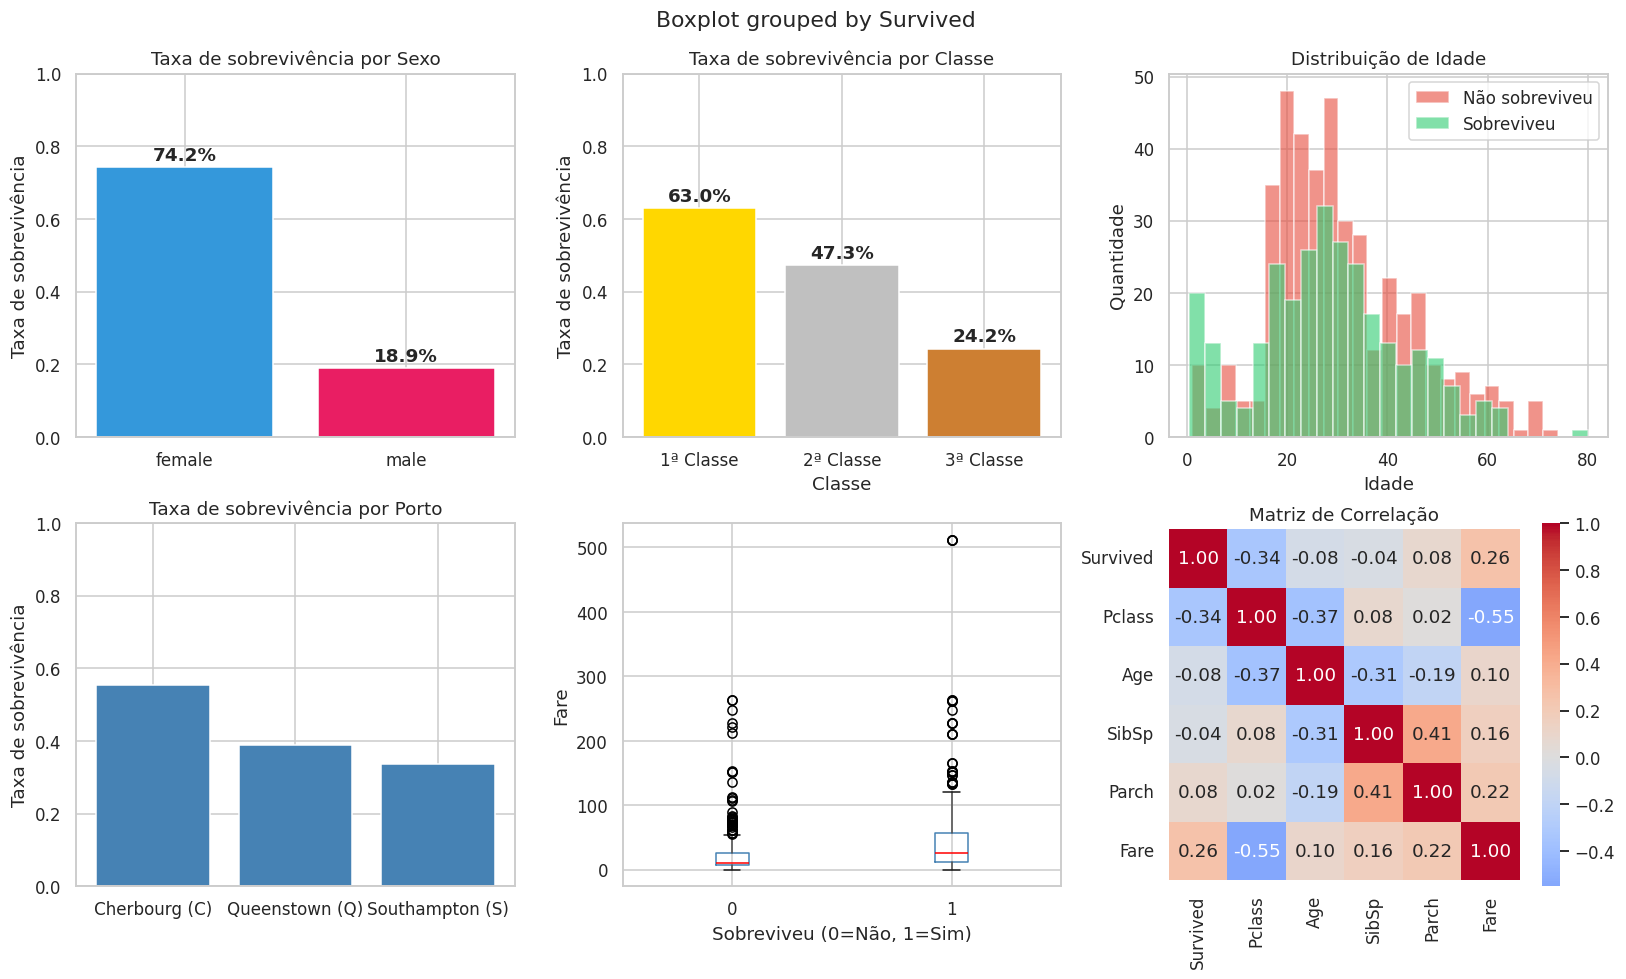

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Análise Exploratória — Titanic', fontsize=14, fontweight='bold')

cores = ['#e74c3c', '#2ecc71']
labels = ['Não sobreviveu', 'Sobreviveu']

# 1. Sobrevivência por sexo
sobrev_sexo = df.groupby('Sex')['Survived'].mean()
axes[0,0].bar(sobrev_sexo.index, sobrev_sexo.values, color=['#3498db','#e91e63'], edgecolor='white')
axes[0,0].set_title('Taxa de sobrevivência por Sexo')
axes[0,0].set_ylabel('Taxa de sobrevivência')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(sobrev_sexo):
    axes[0,0].text(i, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Sobrevivência por classe
sobrev_classe = df.groupby('Pclass')['Survived'].mean()
axes[0,1].bar(sobrev_classe.index, sobrev_classe.values,
              color=['gold','silver','#cd7f32'], edgecolor='white')
axes[0,1].set_title('Taxa de sobrevivência por Classe')
axes[0,1].set_xlabel('Classe'); axes[0,1].set_ylabel('Taxa de sobrevivência')
axes[0,1].set_ylim(0, 1)
axes[0,1].set_xticks([1, 2, 3])
axes[0,1].set_xticklabels(['1ª Classe', '2ª Classe', '3ª Classe'])
for i, v in zip(sobrev_classe.index, sobrev_classe.values):
    axes[0,1].text(i, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Distribuição de idade por sobrevivência
for sobreviveu, cor, label in zip([0, 1], cores, labels):
    subset = df[df['Survived'] == sobreviveu]['Age'].dropna()
    axes[0,2].hist(subset, bins=25, alpha=0.6, color=cor, label=label, edgecolor='white')
axes[0,2].set_title('Distribuição de Idade')
axes[0,2].set_xlabel('Idade'); axes[0,2].set_ylabel('Quantidade')
axes[0,2].legend()

# 4. Sobrevivência por porto de embarque
sobrev_porto = df.groupby('Embarked')['Survived'].mean()
axes[1,0].bar(sobrev_porto.index, sobrev_porto.values, color='steelblue', edgecolor='white')
axes[1,0].set_title('Taxa de sobrevivência por Porto')
axes[1,0].set_xticklabels(['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])
axes[1,0].set_ylabel('Taxa de sobrevivência'); axes[1,0].set_ylim(0, 1)

# 5. Fare vs Sobrevivência (boxplot)
df.boxplot(column='Fare', by='Survived', ax=axes[1,1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
axes[1,1].set_title('Valor da passagem por sobrevivência')
axes[1,1].set_xlabel('Sobreviveu (0=Não, 1=Sim)')
axes[1,1].set_ylabel('Fare'); plt.sca(axes[1,1]); plt.title('')

# 6. Mapa de correlação
cols_num = ['Survived','Pclass','Age','SibSp','Parch','Fare']
corr = df[cols_num].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1,2], square=True)
axes[1,2].set_title('Matriz de Correlação')

plt.tight_layout()
plt.show()

### 5.2 Pré-processamento

Diferente das redes neurais, as **árvores de decisão não requerem normalização**, pois os cortes são baseados em ordem relativa dos valores, não em magnitudes. Porém, ainda precisamos:
1. Tratar **valores faltantes**
2. **Codificar** variáveis categóricas em números

In [7]:
def preprocessar_titanic(df):
    dados = df.copy()

    # 1. Valores faltantes
    dados['Age'].fillna(dados['Age'].median(), inplace=True)      # mediana da idade
    dados['Embarked'].fillna(dados['Embarked'].mode()[0], inplace=True)  # moda do porto
    dados['Fare'].fillna(dados['Fare'].median(), inplace=True)

    # 2. Codificação de categóricos
    dados['Sex']      = (dados['Sex'] == 'female').astype(int)    # female=1, male=0
    dados['Embarked'] = LabelEncoder().fit_transform(dados['Embarked'])

    # 3. Feature engineering simples
    dados['FamilySize'] = dados['SibSp'] + dados['Parch'] + 1     # tamanho da família
    dados['IsAlone']    = (dados['FamilySize'] == 1).astype(int)  # viajando sozinho?

    # 4. Seleciona features
    features = ['Pclass','Sex','Age','SibSp','Parch','Fare',
                'Embarked','FamilySize','IsAlone']
    return dados[features], dados['Survived']

X, y = preprocessar_titanic(df)

print('Features utilizadas:', list(X.columns))
print(f'\nShape: {X.shape}')
print(f'Valores faltantes restantes: {X.isnull().sum().sum()}')
X.head()

Features utilizadas: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']

Shape: (891, 9)
Valores faltantes restantes: 0


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,0,22.0,1,0,7.2500,2,2,0
1,1,1,38.0,1,0,71.2833,0,2,0
2,3,1,26.0,0,0,7.9250,2,1,1
3,1,1,35.0,1,0,53.1000,2,2,0
4,3,0,35.0,0,0,8.0500,2,1,1


In [8]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')
print(f'\nProporção de sobreviventes:')
print(f'  Treino: {y_treino.mean():.2%}')
print(f'  Teste:  {y_teste.mean():.2%}')
print('\n(stratify=y garante que a proporção seja mantida nos dois conjuntos)')

Treino: 712 amostras
Teste:  179 amostras

Proporção de sobreviventes:
  Treino: 38.34%
  Teste:  38.55%

(stratify=y garante que a proporção seja mantida nos dois conjuntos)


## 6. Modelo 1 — Árvore de Decisão

### Principais Hiperparâmetros

| Parâmetro | Descrição | Efeito de aumentar |
|---|---|---|
| `max_depth` | Profundidade máxima | Mais complexo → mais overfitting |
| `min_samples_split` | Mín. de amostras para dividir um nó | Mais conservador → menos overfitting |
| `min_samples_leaf` | Mín. de amostras em uma folha | Mais conservador → menos overfitting |
| `criterion` | Métrica de impureza (`gini` ou `entropy`) | — |

In [9]:
# Treina a árvore
arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore.fit(X_treino, y_treino)

acc_tr = arvore.score(X_treino, y_treino)
acc_ts = arvore.score(X_teste,  y_teste)

print(f'Acurácia — Treino: {acc_tr:.4f}  |  Teste: {acc_ts:.4f}')
print(f'Número de folhas: {arvore.get_n_leaves()}')
print(f'Profundidade real: {arvore.get_depth()}')

Acurácia — Treino: 0.8385  |  Teste: 0.7877
Número de folhas: 15
Profundidade real: 4


### 6.1 Visualizando a Árvore Completa

Esta é a grande vantagem: podemos **ler** a lógica do modelo.

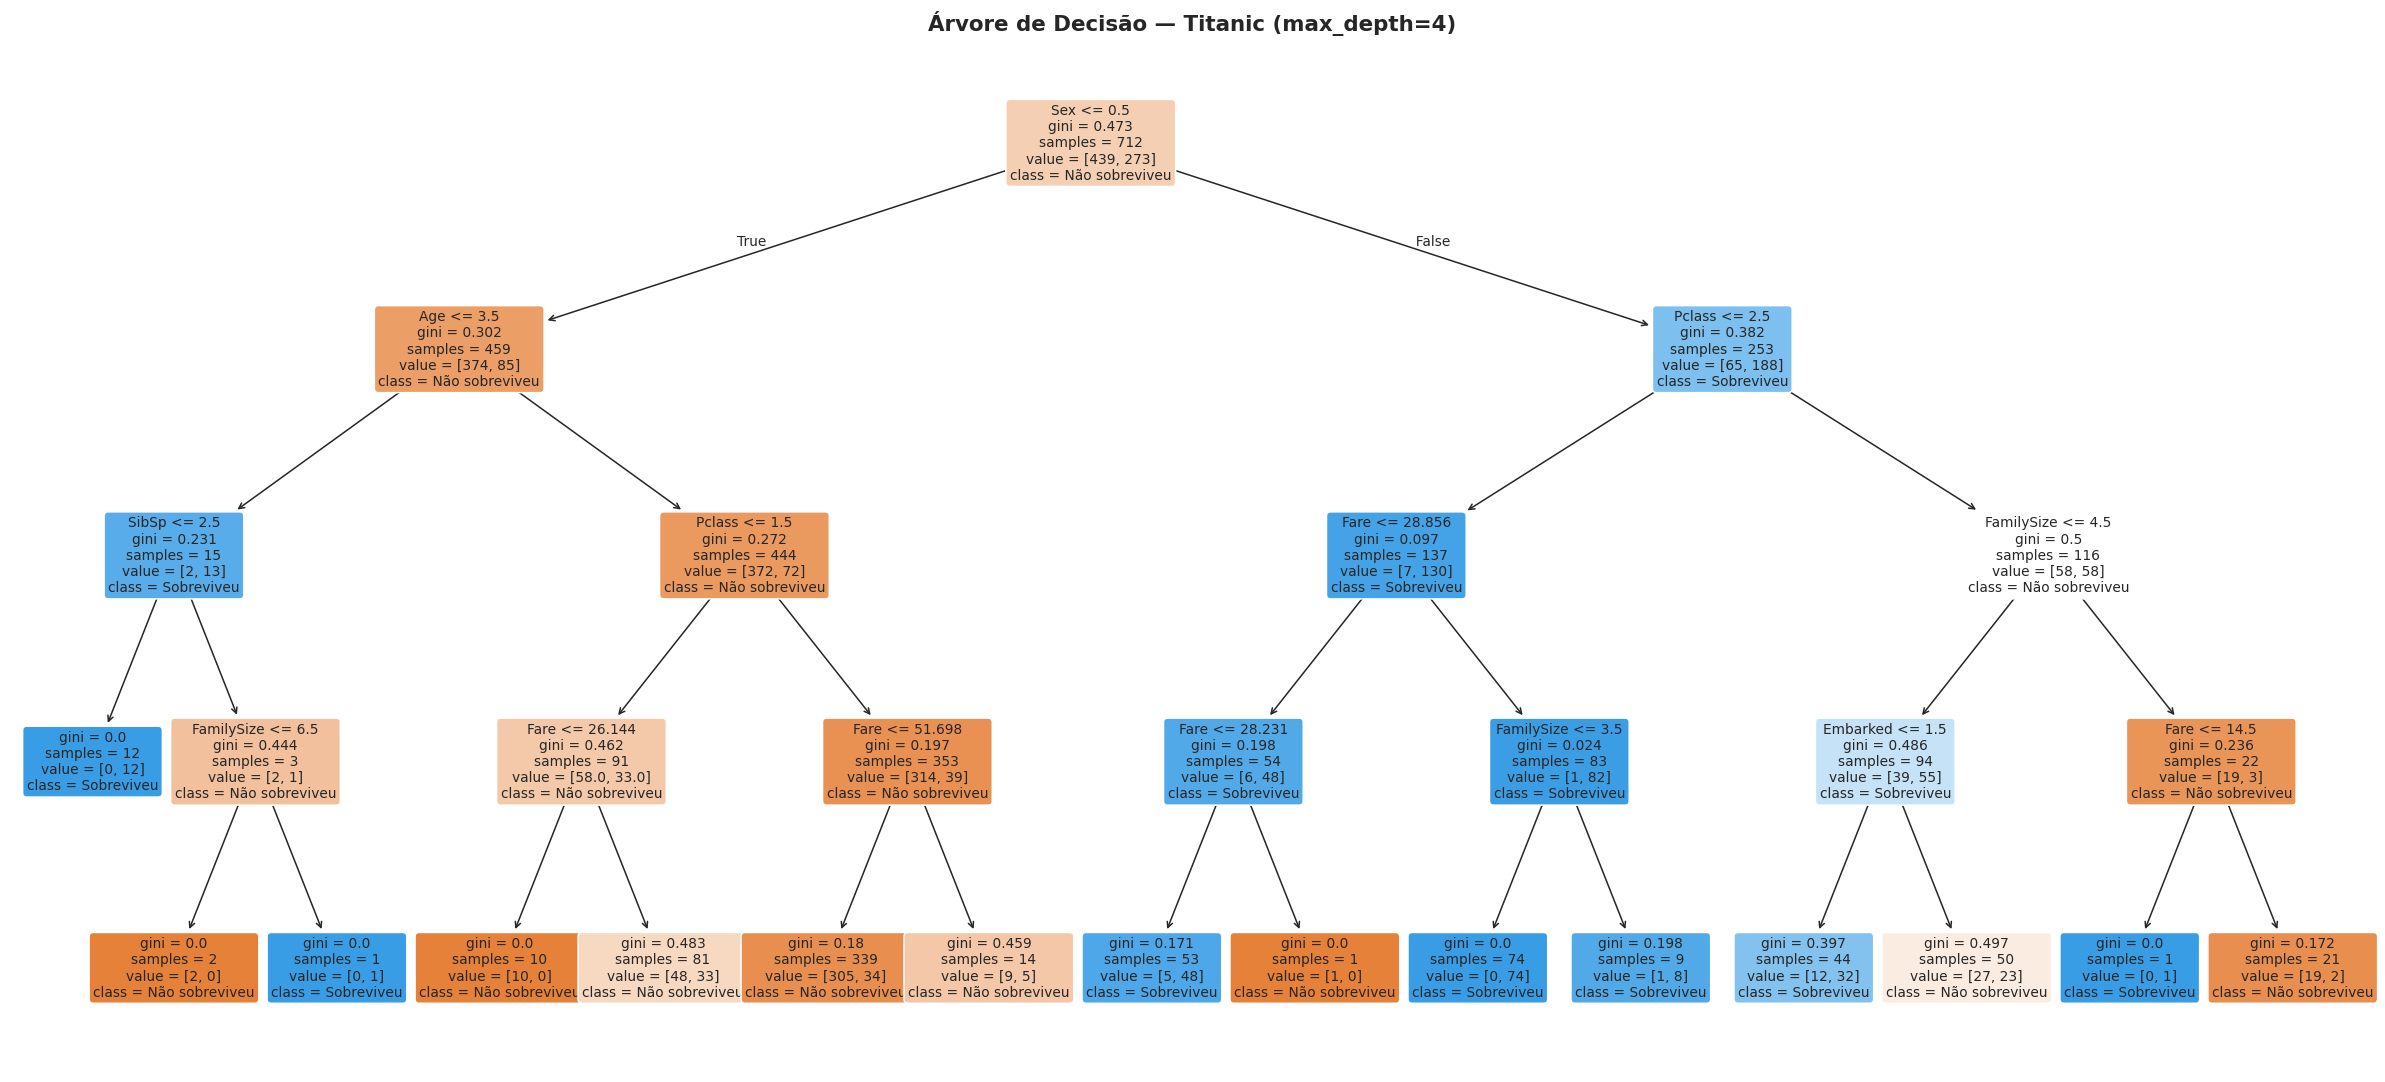

In [10]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    arvore,
    feature_names=X.columns.tolist(),
    class_names=['Não sobreviveu', 'Sobreviveu'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Árvore de Decisão — Titanic (max_depth=4)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Versão textual (fácil de inspecionar no terminal)
regras = export_text(arvore, feature_names=X.columns.tolist())
print('=== Regras da Árvore (formato texto) ===')
print(regras)

=== Regras da Árvore (formato texto) ===
|--- Sex <= 0.50
|   |--- Age <= 3.50
|   |   |--- SibSp <= 2.50
|   |   |   |--- class: 1
|   |   |--- SibSp >  2.50
|   |   |   |--- FamilySize <= 6.50
|   |   |   |   |--- class: 0
|   |   |   |--- FamilySize >  6.50
|   |   |   |   |--- class: 1
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- Fare <= 26.14
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  26.14
|   |   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- Fare <= 51.70
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  51.70
|   |   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- Fare <= 28.23
|   |   |   |   |--- class: 1
|   |   |   |--- Fare >  28.23
|   |   |   |   |--- class: 0
|   |   |--- Fare >  28.86
|   |   |   |--- FamilySize <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- FamilySize >  3.50
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fa

### 6.2 Análise do Overfitting: Profundidade × Acurácia

Vamos ver sistematicamente como a profundidade afeta o treino e o teste.

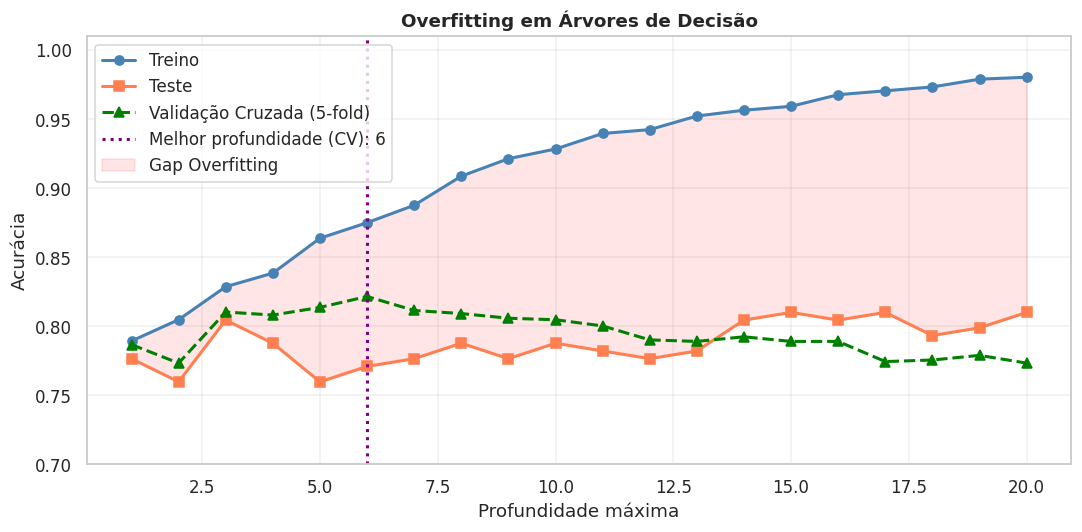

Melhor profundidade pela validação cruzada: 6
Acurácia no teste com profundidade 6: 0.7709


In [12]:
profundidades = range(1, 21)
accs_treino, accs_teste, accs_cv = [], [], []

for p in profundidades:
    a = DecisionTreeClassifier(max_depth=p, random_state=42)
    a.fit(X_treino, y_treino)
    accs_treino.append(a.score(X_treino, y_treino))
    accs_teste.append(a.score(X_teste, y_teste))
    # Validação cruzada dá uma estimativa mais robusta
    accs_cv.append(cross_val_score(a, X, y, cv=5, scoring='accuracy').mean())

melhor_p = profundidades[np.argmax(accs_cv)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(profundidades, accs_treino, 'o-', label='Treino',
        color='steelblue', linewidth=2)
ax.plot(profundidades, accs_teste,  's-', label='Teste',
        color='coral', linewidth=2)
ax.plot(profundidades, accs_cv,     '^--', label='Validação Cruzada (5-fold)',
        color='green', linewidth=2)
ax.axvline(melhor_p, color='purple', linestyle=':', linewidth=2,
           label=f'Melhor profundidade (CV): {melhor_p}')
ax.fill_between(profundidades, accs_treino, accs_teste,
                alpha=0.1, color='red', label='Gap Overfitting')
ax.set_xlabel('Profundidade máxima'); ax.set_ylabel('Acurácia')
ax.set_title('Overfitting em Árvores de Decisão', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim([0.7, 1.01])
plt.tight_layout()
plt.show()
print(f'Melhor profundidade pela validação cruzada: {melhor_p}')
print(f'Acurácia no teste com profundidade {melhor_p}: {accs_teste[melhor_p-1]:.4f}')

## 7. Modelo 2 — Random Forest

### O Problema das Árvores Individuais

Árvores de decisão são **instáveis**: uma pequena mudança nos dados de treino pode gerar uma árvore completamente diferente. Isso é chamado de **alta variância**.

### A Solução: Ensemble por Bagging

Random Forest treina **N árvores independentes** e combina suas previsões por **votação da maioria**.

Cada árvore é treinada com duas fontes de aleatoriedade:

1. **Bootstrap sampling**: cada árvore vê uma amostra **aleatória com reposição** dos dados de treino (~63% do original)
2. **Feature randomness**: em cada divisão, apenas um **subconjunto aleatório de features** é considerado (padrão: $\sqrt{\text{n\_features}}$)

```
Dados originais (N amostras)
        ↓
┌──────────────────────────────────────────┐
│  Bootstrap 1  │  Bootstrap 2  │  ...  │  Bootstrap K  │
│  Árvore 1     │  Árvore 2     │  ...  │  Árvore K     │
│  Pred. 1      │  Pred. 2      │  ...  │  Pred. K      │
└──────────────────────────────────────────┘
                       ↓
              Votação da maioria
                       ↓
               Previsão final
```

> **Por que funciona?** Erros individuais de cada árvore tendem a se cancelar na votação. É o princípio da **"sabedoria das multidões"**.

In [13]:
# Treina o Random Forest
floresta = RandomForestClassifier(
    n_estimators=100,   # número de árvores
    max_depth=10,       # profundidade de cada árvore
    random_state=42,
    n_jobs=-1           # usa todos os núcleos da CPU
)
floresta.fit(X_treino, y_treino)

acc_rf_tr = floresta.score(X_treino, y_treino)
acc_rf_ts = floresta.score(X_teste,  y_teste)

print('=== Resultados ===')
print(f'{'Modelo':<20} {'Treino':>8} {'Teste':>8}')
print('-' * 38)
print(f'{'Árvore (depth=4)':<20} {acc_tr:>8.4f} {acc_ts:>8.4f}')
print(f'{'Random Forest':<20} {acc_rf_tr:>8.4f} {acc_rf_ts:>8.4f}')

=== Resultados ===
Modelo                 Treino    Teste
--------------------------------------
Árvore (depth=4)       0.8385   0.7877
Random Forest          0.9537   0.8212


### 7.1 Impacto do Número de Árvores

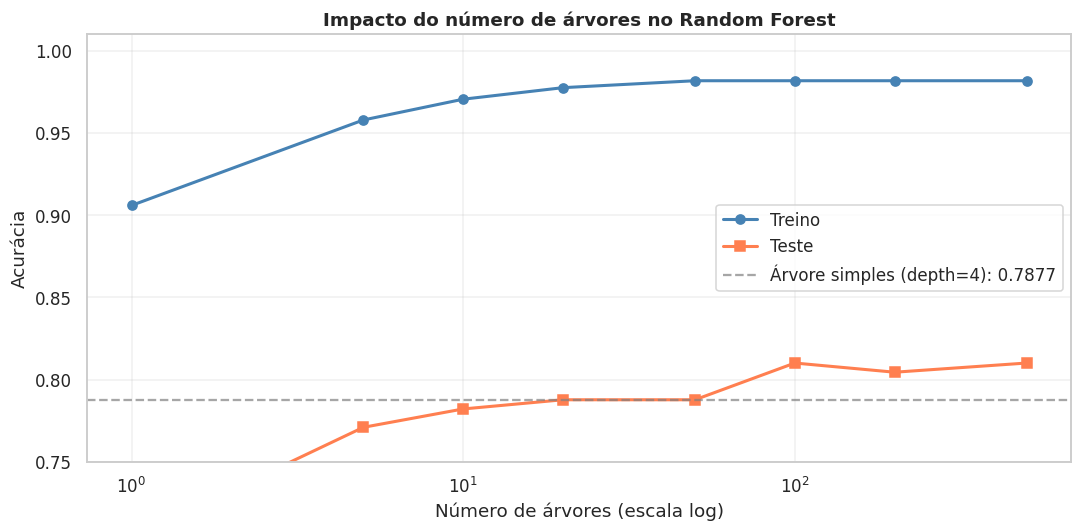

Observe: acima de ~50 árvores, o ganho marginal diminui (lei dos retornos decrescentes)


In [14]:
n_arvores = [1, 5, 10, 20, 50, 100, 200, 500]
accs_rf_treino, accs_rf_teste = [], []

for n in n_arvores:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_treino, y_treino)
    accs_rf_treino.append(rf.score(X_treino, y_treino))
    accs_rf_teste.append(rf.score(X_teste, y_teste))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(n_arvores, accs_rf_treino, 'o-', label='Treino',
            color='steelblue', linewidth=2)
ax.semilogx(n_arvores, accs_rf_teste,  's-', label='Teste',
            color='coral', linewidth=2)
ax.axhline(acc_ts, color='gray', linestyle='--', alpha=0.7,
           label=f'Árvore simples (depth=4): {acc_ts:.4f}')
ax.set_xlabel('Número de árvores (escala log)')
ax.set_ylabel('Acurácia')
ax.set_title('Impacto do número de árvores no Random Forest', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim([0.75, 1.01])
plt.tight_layout()
plt.show()
print('Observe: acima de ~50 árvores, o ganho marginal diminui (lei dos retornos decrescentes)')

## 8. Importância das Features

O Random Forest calcula automaticamente a **importância** de cada feature: quanto, em média, cada feature reduz a impureza em todas as árvores da floresta.

Isso é extremamente útil para:
- **Seleção de features**: remover features irrelevantes
- **Interpretação do modelo**: entender o que o modelo usa para decidir
- **Descoberta de conhecimento**: encontrar padrões nos dados

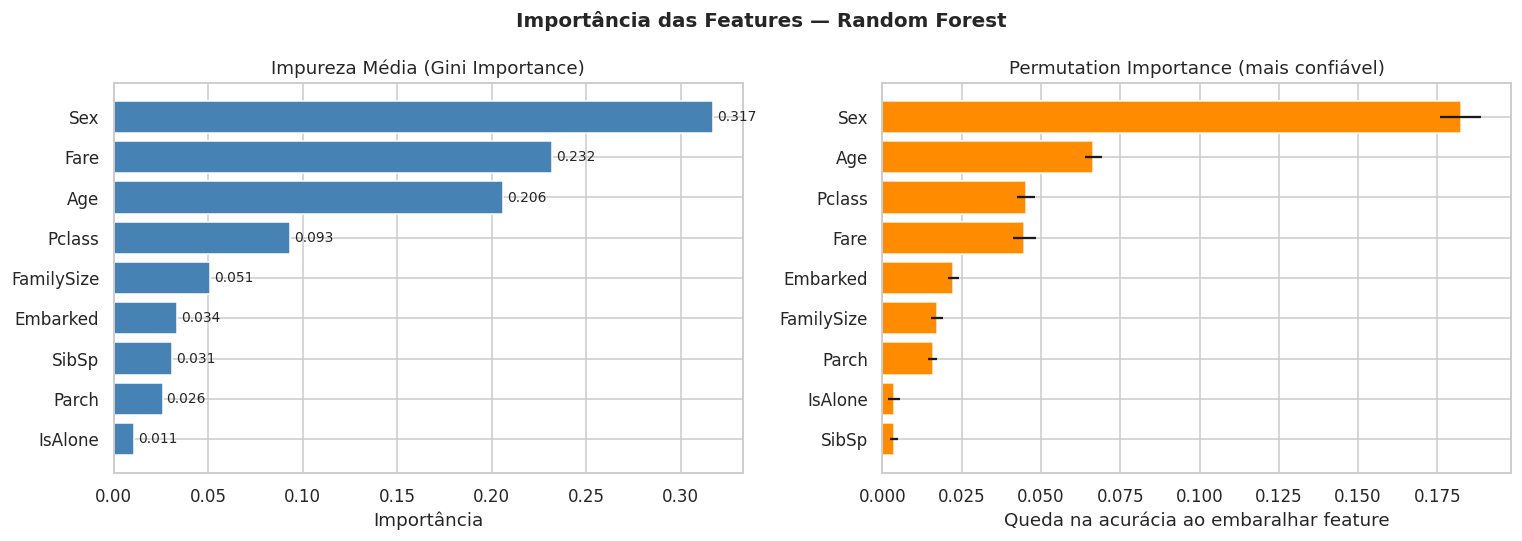

Feature mais importante: Sex

Interpretação: embaralhar "Sex" causa a maior queda de acurácia,
confirmando que sexo foi o fator mais determinante para sobrevivência.


In [15]:
# Importância baseada em impureza (padrão do sklearn)
importancias = pd.Series(floresta.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

# Permutation importance (mais confiável, mas mais lenta)
perm_imp = permutation_importance(floresta, X_teste, y_teste,
                                   n_repeats=20, random_state=42)
perm_importancias = pd.Series(
    perm_imp.importances_mean, index=X.columns
).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Importância das Features — Random Forest', fontsize=13, fontweight='bold')

# Gráfico 1: impureza
bars = ax1.barh(importancias.index, importancias.values, color='steelblue', edgecolor='white')
ax1.set_title('Impureza Média (Gini Importance)')
ax1.set_xlabel('Importância')
for bar, val in zip(bars, importancias.values):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# Gráfico 2: permutação
bars2 = ax2.barh(perm_importancias.index, perm_importancias.values,
                  color='darkorange', edgecolor='white')
ax2.set_title('Permutation Importance (mais confiável)')
ax2.set_xlabel('Queda na acurácia ao embaralhar feature')
erros = [perm_imp.importances_std[list(X.columns).index(feat)] / np.sqrt(20)
         for feat in perm_importancias.index]
ax2.barh(perm_importancias.index, perm_importancias.values,
          xerr=erros, color='darkorange', edgecolor='white', alpha=0.8)

plt.tight_layout()
plt.show()

print('Feature mais importante:', importancias.idxmax())
print('\nInterpretação: embaralhar "Sex" causa a maior queda de acurácia,')
print('confirmando que sexo foi o fator mais determinante para sobrevivência.')

## 9. Avaliação Completa dos Modelos

### 9.1 Matrizes de Confusão

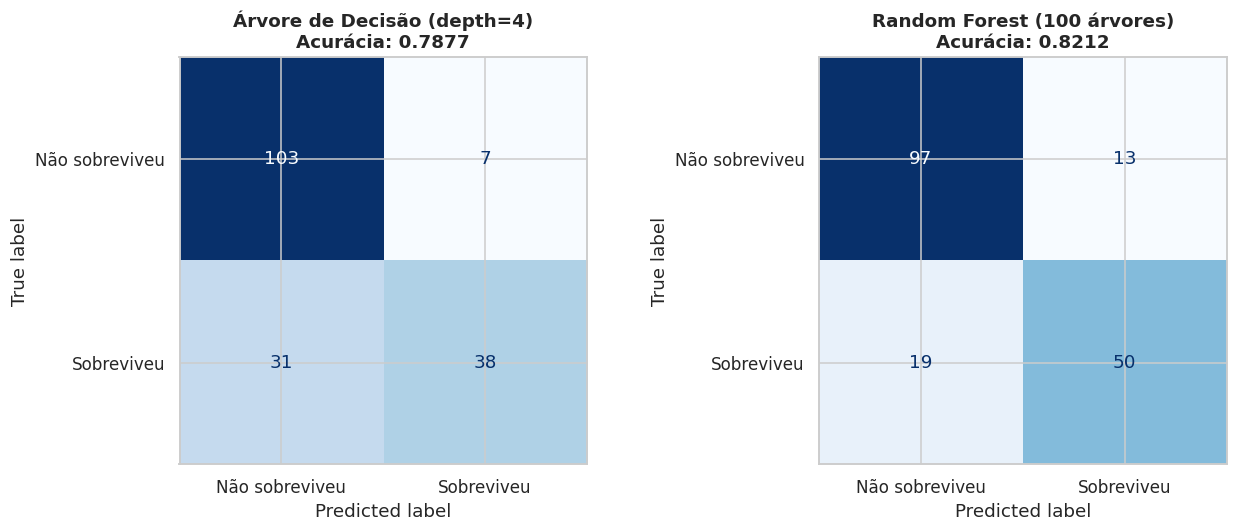

In [16]:
y_pred_arvore  = arvore.predict(X_teste)
y_pred_floresta = floresta.predict(X_teste)
y_prob_floresta = floresta.predict_proba(X_teste)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titulo, acc in [
    (ax1, y_pred_arvore,   f'Árvore de Decisão (depth=4)\nAcurácia: {acc_ts:.4f}',   acc_ts),
    (ax2, y_pred_floresta, f'Random Forest (100 árvores)\nAcurácia: {acc_rf_ts:.4f}', acc_rf_ts),
]:
    cm = confusion_matrix(y_teste, y_pred)
    disp = ConfusionMatrixDisplay(
        cm, display_labels=['Não sobreviveu', 'Sobreviveu']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
print('=== Relatório Completo — Random Forest ===')
print(classification_report(
    y_teste, y_pred_floresta,
    target_names=['Não sobreviveu', 'Sobreviveu']
))

=== Relatório Completo — Random Forest ===
                precision    recall  f1-score   support

Não sobreviveu       0.84      0.88      0.86       110
    Sobreviveu       0.79      0.72      0.76        69

      accuracy                           0.82       179
     macro avg       0.81      0.80      0.81       179
  weighted avg       0.82      0.82      0.82       179



### 9.2 Curva ROC e AUC

A **curva ROC** (Receiver Operating Characteristic) mostra o tradeoff entre **taxa de verdadeiros positivos** (recall) e **taxa de falsos positivos** para diferentes limiares de classificação.

O **AUC** (Area Under the Curve) resume a curva em um único número:
- **AUC = 0,5**: modelo aleatório
- **AUC = 1,0**: modelo perfeito

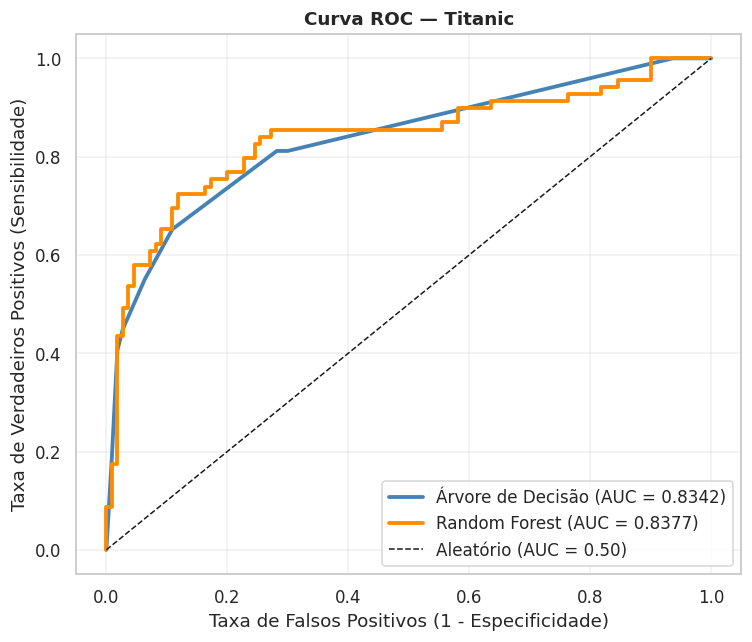

In [18]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

y_prob_arvore   = arvore.predict_proba(X_teste)[:, 1]
y_prob_floresta = floresta.predict_proba(X_teste)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, nome, cor in [
    (y_prob_arvore,   'Árvore de Decisão', 'steelblue'),
    (y_prob_floresta, 'Random Forest',     'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_teste, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.5, color=cor,
            label=f'{nome} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.50)')
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
ax.set_title('Curva ROC — Titanic', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 Validação Cruzada Estratificada

A validação cruzada dá uma estimativa mais robusta da performance real, pois avalia o modelo em **5 conjuntos de teste diferentes**.

Modelo                       Média      Std      Min      Max
------------------------------------------------------------
Árvore (depth=4)            0.8170   0.0154   0.7921   0.8371
Árvore (depth=6)            0.8137   0.0333   0.7472   0.8324
Random Forest (100)         0.8182   0.0276   0.7697   0.8483


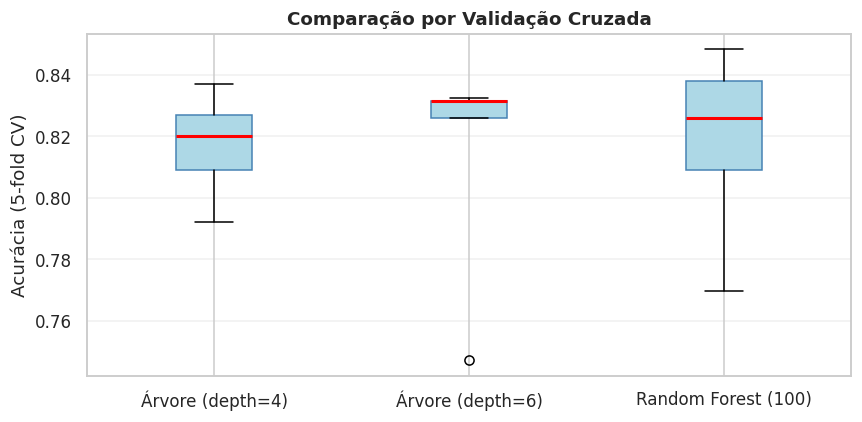

In [19]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Árvore (depth=4)':   DecisionTreeClassifier(max_depth=4, random_state=42),
    f'Árvore (depth={melhor_p})': DecisionTreeClassifier(max_depth=melhor_p, random_state=42),
    'Random Forest (100)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

print(f'{'Modelo':<25} {'Média':>8} {'Std':>8} {'Min':>8} {'Max':>8}')
print('-' * 60)

resultados_cv = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=skf, scoring='accuracy')
    resultados_cv[nome] = scores
    print(f'{nome:<25} {scores.mean():>8.4f} {scores.std():>8.4f} '
          f'{scores.min():>8.4f} {scores.max():>8.4f}')

# Boxplot comparativo
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Acurácia (5-fold CV)')
ax.set_title('Comparação por Validação Cruzada', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Otimização de Hiperparâmetros com GridSearchCV

Em vez de testar manualmente cada combinação de hiperparâmetros, podemos usar o **GridSearchCV** para fazer isso automaticamente com validação cruzada.

In [20]:
# Grid de hiperparâmetros para o Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, None],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_treino, y_treino)

print(f'\nMelhores hiperparâmetros: {grid_search.best_params_}')
print(f'Melhor acurácia (CV):    {grid_search.best_score_:.4f}')

# Avalia o melhor modelo no teste
melhor_rf = grid_search.best_estimator_
acc_melhor = melhor_rf.score(X_teste, y_teste)
print(f'Acurácia no teste:       {acc_melhor:.4f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Melhores hiperparâmetros: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}
Melhor acurácia (CV):    0.8161
Acurácia no teste:       0.8045


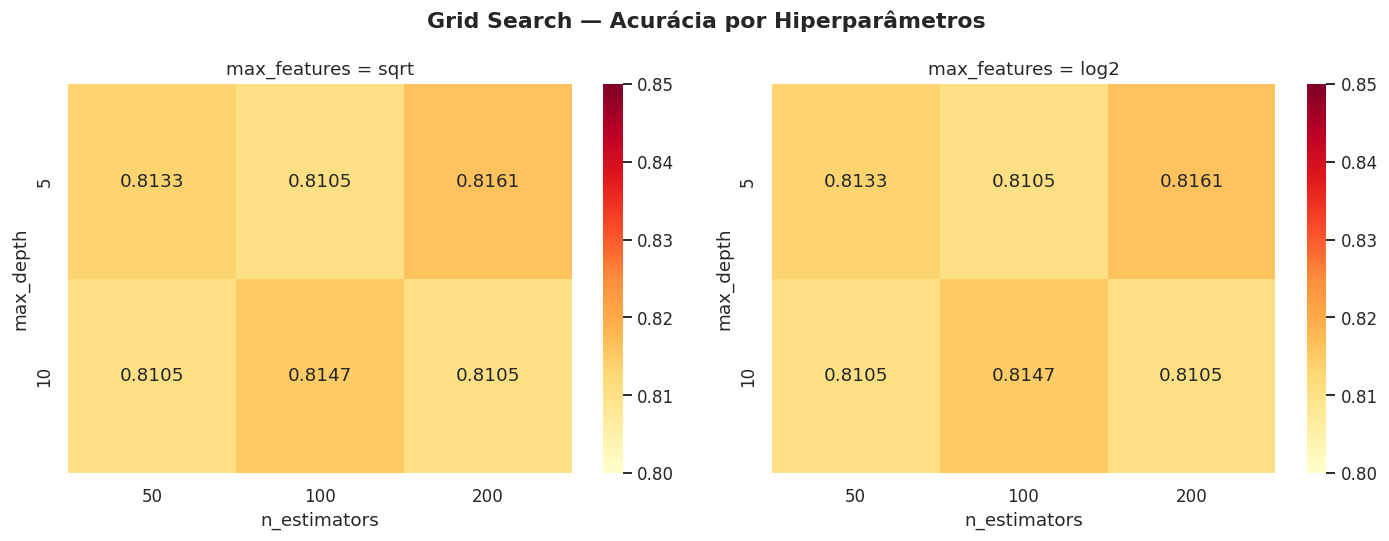

In [21]:
# Visualiza o resultado do grid search como heatmap
resultados_grid = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Grid Search — Acurácia por Hiperparâmetros', fontweight='bold')

for ax, max_feat in zip(axes, ['sqrt', 'log2']):
    subset = resultados_grid[resultados_grid['param_max_features'] == max_feat]
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_n_estimators'
    )
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                ax=ax, vmin=0.80, vmax=0.85)
    ax.set_title(f'max_features = {max_feat}')
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('max_depth')

plt.tight_layout()
plt.show()

## 11. Fazendo Previsões para Novos Passageiros

Vamos usar o melhor modelo para prever a sobrevivência de passageiros criados manualmente.

In [22]:
def prever_passageiro(pclass, sexo, idade, sibsp, parch, fare, embarked):
    """
    pclass: 1, 2 ou 3
    sexo: 'male' ou 'female'
    embarked: 'C' (Cherbourg), 'Q' (Queenstown), 'S' (Southampton)
    """
    sex_enc = 1 if sexo == 'female' else 0
    emb_enc = {'C': 0, 'Q': 1, 'S': 2}.get(embarked, 2)
    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0

    entrada = pd.DataFrame([[
        pclass, sex_enc, idade, sibsp, parch,
        fare, emb_enc, family_size, is_alone
    ]], columns=X.columns)

    prob_sobreviveu = melhor_rf.predict_proba(entrada)[0][1]
    previsao = 'SOBREVIVEU ✅' if prob_sobreviveu >= 0.5 else 'NÃO SOBREVIVEU ❌'

    print(f'Passageiro: {pclass}ª classe, {sexo}, {idade} anos')
    print(f'Previsão:   {previsao}')
    print(f'Probabilidade de sobrevivência: {prob_sobreviveu:.1%}\n')

print('=== Previsões para novos passageiros ===')
print()
prever_passageiro(pclass=1, sexo='female', idade=28, sibsp=0, parch=0, fare=100, embarked='C')
prever_passageiro(pclass=3, sexo='male',   idade=22, sibsp=0, parch=0, fare=8,   embarked='S')
prever_passageiro(pclass=2, sexo='female', idade=35, sibsp=1, parch=2, fare=26,  embarked='S')
prever_passageiro(pclass=1, sexo='male',   idade=50, sibsp=0, parch=0, fare=150, embarked='C')

=== Previsões para novos passageiros ===

Passageiro: 1ª classe, female, 28 anos
Previsão:   SOBREVIVEU ✅
Probabilidade de sobrevivência: 95.1%

Passageiro: 3ª classe, male, 22 anos
Previsão:   NÃO SOBREVIVEU ❌
Probabilidade de sobrevivência: 11.3%

Passageiro: 2ª classe, female, 35 anos
Previsão:   SOBREVIVEU ✅
Probabilidade de sobrevivência: 83.9%

Passageiro: 1ª classe, male, 50 anos
Previsão:   NÃO SOBREVIVEU ❌
Probabilidade de sobrevivência: 37.4%



## 12. Exercícios Propostos

---



### Exercício 1 — Poda por Folhas

Em vez de controlar o overfitting pela profundidade, use o hiperparâmetro `min_samples_leaf`. Treine árvores com diferentes valores (1, 5, 10, 20, 50) e plote a curva treino × teste.

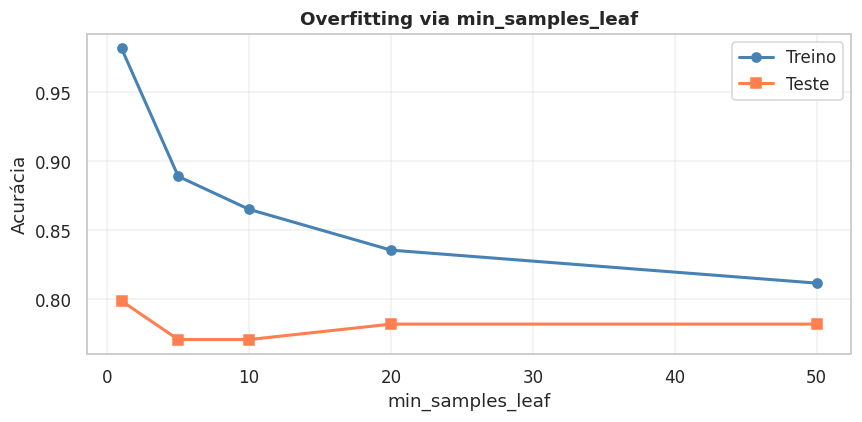

Melhor min_samples_leaf: 1
Acurácia no teste: 0.7989


In [29]:
# Exercício 1: Controle de overfitting via min_samples_leaf
valores_leaf = [1, 5, 10, 20, 50]
accs_treino_leaf, accs_teste_leaf = [], []

for leaf in valores_leaf:
    a = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    a.fit(X_treino, y_treino)
    accs_treino_leaf.append(a.score(X_treino, y_treino))
    accs_teste_leaf.append(a.score(X_teste, y_teste))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(valores_leaf, accs_treino_leaf, 'o-', label='Treino', color='steelblue', linewidth=2)
ax.plot(valores_leaf, accs_teste_leaf,  's-', label='Teste',  color='coral',     linewidth=2)
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Acurácia')
ax.set_title('Overfitting via min_samples_leaf', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

melhor_leaf = valores_leaf[accs_teste_leaf.index(max(accs_teste_leaf))]
print(f'Melhor min_samples_leaf: {melhor_leaf}')
print(f'Acurácia no teste: {max(accs_teste_leaf):.4f}')


### Exercício 2 — Novo Dataset: Breast Cancer

Aplique a Árvore de Decisão e o Random Forest no dataset de diagnóstico de câncer de mama (`load_breast_cancer` do sklearn). Compare as acurácias e interprete as features mais importantes.

Dataset: .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of dista ...

Shape: (569, 30)
Classes: ['malignant' 'benign']

Acurácia — Árvore:  0.9386
Acurácia — Floresta: 0.9561

=== Relatório — Random Forest (Breast Cancer) ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



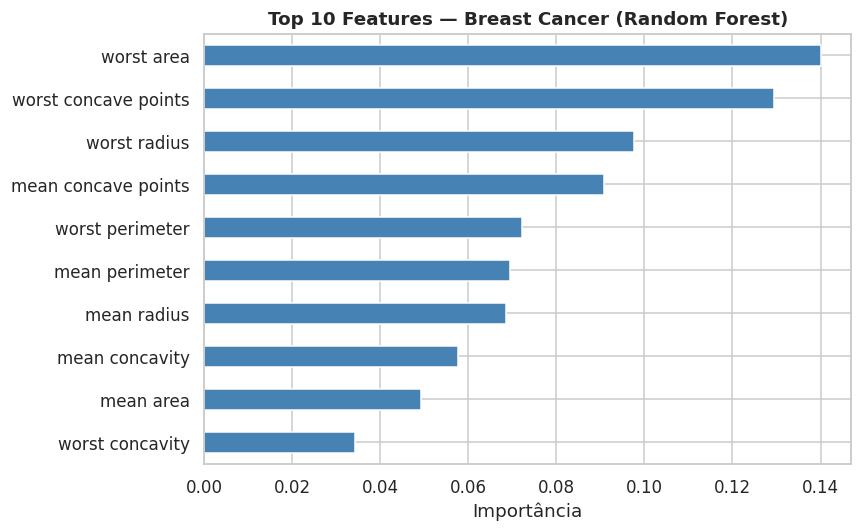

In [30]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = cancer.target

print('Dataset:', cancer.DESCR[:300], '...')
print(f'\nShape: {X_c.shape}')
print(f'Classes: {cancer.target_names}')

# 1. Dividir em treino e teste
X_c_tr, X_c_ts, y_c_tr, y_c_ts = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

# 2. Treinar Árvore e Random Forest
arvore_c  = DecisionTreeClassifier(max_depth=4, random_state=42)
floresta_c = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
arvore_c.fit(X_c_tr, y_c_tr)
floresta_c.fit(X_c_tr, y_c_tr)

# 3. Avaliar
print(f'\nAcurácia — Árvore:  {arvore_c.score(X_c_ts, y_c_ts):.4f}')
print(f'Acurácia — Floresta: {floresta_c.score(X_c_ts, y_c_ts):.4f}')

y_pred_c = floresta_c.predict(X_c_ts)
print('\n=== Relatório — Random Forest (Breast Cancer) ===')
print(classification_report(y_c_ts, y_pred_c, target_names=cancer.target_names))

# 4. Top 10 features mais importantes
imp = pd.Series(floresta_c.feature_importances_, index=X_c.columns).nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Features — Breast Cancer (Random Forest)', fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()


### Exercício 3 — Fronteiras de Decisão no Iris

O dataset Iris tem 4 features e 3 classes. Use **PCA** para reduzir para 2 dimensões e plote as fronteiras de decisão da Árvore e do Random Forest lado a lado.

Variância explicada pelos 2 componentes: 97.77%


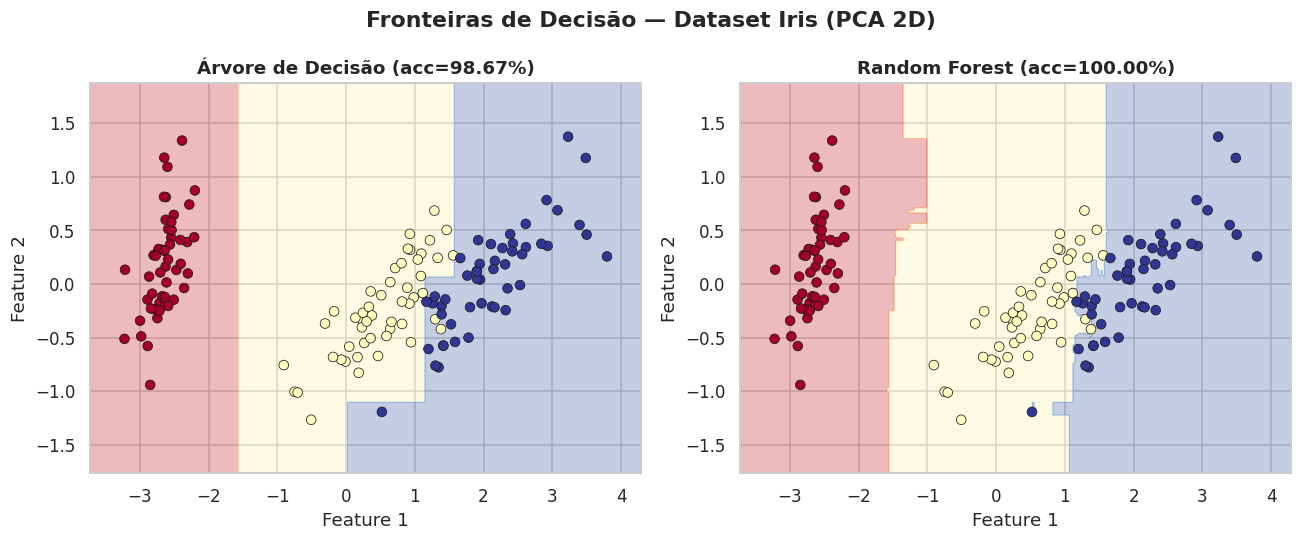

Observe: a Árvore faz cortes retangulares; o Random Forest forma fronteiras mais suaves.


In [31]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Reduz para 2D com PCA para visualização
pca = PCA(n_components=2, random_state=42)
X_iris_2d = pca.fit_transform(X_iris)

print(f'Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.2%}')

# 1. Treinar Árvore e Random Forest nos dados 2D
arvore_iris  = DecisionTreeClassifier(max_depth=4, random_state=42)
floresta_iris = RandomForestClassifier(n_estimators=100, random_state=42)
arvore_iris.fit(X_iris_2d, y_iris)
floresta_iris.fit(X_iris_2d, y_iris)

# 2. Plotar fronteiras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Fronteiras de Decisão — Dataset Iris (PCA 2D)', fontweight='bold')

for ax, modelo, titulo in [
    (axes[0], arvore_iris,  f'Árvore de Decisão (acc={arvore_iris.score(X_iris_2d, y_iris):.2%})'),
    (axes[1], floresta_iris, f'Random Forest (acc={floresta_iris.score(X_iris_2d, y_iris):.2%})'),
]:
    plotar_fronteira(modelo, X_iris_2d, y_iris, titulo, ax)

plt.tight_layout()
plt.show()
print('Observe: a Árvore faz cortes retangulares; o Random Forest forma fronteiras mais suaves.')


### Exercício 4 — Feature Engineering

Crie novas features a partir das originais do Titanic e veja se a acurácia melhora:

- `Title`: extraído do nome (`Mr`, `Mrs`, `Miss`, `Master`, etc.)
- `CabinKnown`: se o número da cabine é conhecido (1/0)
- `AgeGroup`: faixas de idade (criança, adulto jovem, adulto, idoso)

In [32]:
# Exercício 4: Feature Engineering
df_eng = df.copy()

# 1. Criar novas features
df_eng['Title'] = df_eng['Name'].str.extract(r',\s*([^\.]+)\.')
# Simplifica títulos raros
df_eng['Title'] = df_eng['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
     'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Raro'
)
df_eng['Title'] = df_eng['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

df_eng['CabinKnown'] = df_eng['Cabin'].notna().astype(int)
df_eng['AgeGroup'] = pd.cut(
    df_eng['Age'].fillna(df_eng['Age'].median()),
    bins=[0, 12, 25, 60, 100],
    labels=[0, 1, 2, 3]
).astype(int)

# 2. Pré-processar igual ao baseline + novas features
df_eng['Age'].fillna(df_eng['Age'].median(), inplace=True)
df_eng['Embarked'].fillna(df_eng['Embarked'].mode()[0], inplace=True)
df_eng['Sex']      = (df_eng['Sex'] == 'female').astype(int)
df_eng['Embarked'] = LabelEncoder().fit_transform(df_eng['Embarked'])
df_eng['Title']    = LabelEncoder().fit_transform(df_eng['Title'])
df_eng['FamilySize'] = df_eng['SibSp'] + df_eng['Parch'] + 1
df_eng['IsAlone']    = (df_eng['FamilySize'] == 1).astype(int)

features_eng = ['Pclass','Sex','Age','SibSp','Parch','Fare',
                'Embarked','FamilySize','IsAlone',
                'Title','CabinKnown','AgeGroup']
X_eng = df_eng[features_eng]
y_eng = df_eng['Survived']

X_eng_tr, X_eng_ts, y_eng_tr, y_eng_ts = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

# 3. Treinar e comparar
rf_eng = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_eng.fit(X_eng_tr, y_eng_tr)
acc_eng = rf_eng.score(X_eng_ts, y_eng_ts)

print(f'Acurácia baseline (sem FE):   {acc_rf_ts:.4f}')
print(f'Acurácia com feature engineering: {acc_eng:.4f}')
print(f'Melhora: {acc_eng - acc_rf_ts:+.4f}')


Acurácia baseline (sem FE):   0.8212
Acurácia com feature engineering: 0.8101
Melhora: -0.0112


## 13. Resumo da Aula

In [27]:
# Tabela final comparativa
print('=' * 65)
print(f"{'Modelo':<28} {'Acurácia Teste':>15} {'AUC (ROC)':>10}")
print('-' * 65)

from sklearn.metrics import roc_auc_score
modelos_finais = [
    ('Árvore (depth=4)',          acc_ts,    roc_auc_score(y_teste, y_prob_arvore)),
    (f'Árvore (depth={melhor_p})', accs_teste[melhor_p-1],
     roc_auc_score(y_teste, DecisionTreeClassifier(max_depth=melhor_p, random_state=42)
                   .fit(X_treino, y_treino).predict_proba(X_teste)[:, 1])),
    ('Random Forest (100)',        acc_rf_ts, roc_auc_score(y_teste, y_prob_floresta)),
    ('Random Forest (otimizado)',  acc_melhor, roc_auc_score(y_teste,
                                              melhor_rf.predict_proba(X_teste)[:, 1])),
]

for nome, acc, auc_val in modelos_finais:
    print(f'{nome:<28} {acc:>15.4f} {auc_val:>10.4f}')

print('=' * 65)

print('\n=== Conceitos-chave desta aula ===')
conceitos = [
    '✓ Árvore de Decisão: divisões binárias no espaço de features',
    '✓ Impureza de Gini e Entropia: critérios para escolher divisões',
    '✓ Overfitting: árvores profundas memorizam o treino',
    '✓ Poda: max_depth, min_samples_leaf controlam a complexidade',
    '✓ Random Forest: ensemble de árvores com bagging + aleatoriedade',
    '✓ Feature Importance: o RF revela quais variáveis importam mais',
    '✓ GridSearchCV: busca automática dos melhores hiperparâmetros',
    '✓ Curva ROC / AUC: avaliação independente do limiar de decisão',
    '✓ Validação cruzada: estimativa robusta da performance real',
]
for c in conceitos:
    print(c)

Modelo                        Acurácia Teste  AUC (ROC)
-----------------------------------------------------------------
Árvore (depth=4)                      0.7877     0.8342
Árvore (depth=6)                      0.7709     0.7618
Random Forest (100)                   0.8212     0.8377
Random Forest (otimizado)             0.8045     0.8450

=== Conceitos-chave desta aula ===
✓ Árvore de Decisão: divisões binárias no espaço de features
✓ Impureza de Gini e Entropia: critérios para escolher divisões
✓ Overfitting: árvores profundas memorizam o treino
✓ Poda: max_depth, min_samples_leaf controlam a complexidade
✓ Random Forest: ensemble de árvores com bagging + aleatoriedade
✓ Feature Importance: o RF revela quais variáveis importam mais
✓ GridSearchCV: busca automática dos melhores hiperparâmetros
✓ Curva ROC / AUC: avaliação independente do limiar de decisão
✓ Validação cruzada: estimativa robusta da performance real


---

## Referências

1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
2. Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and Regression Trees*. CRC Press.
3. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2ª ed.). Springer. https://web.stanford.edu/~hastie/ElemStatLearn/
4. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3ª ed.). O'Reilly.
5. Documentação do scikit-learn: https://scikit-learn.org/stable/modules/tree.html
6. Dataset Titanic: https://www.kaggle.com/c/titanic

---
*Notebook criado para a disciplina de Inteligência Artificial — Ciência da Computação*